# Data analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

plt.rcParams["figure.figsize"] = (8, 4)


## Load dataset

In [7]:
# Expected structure:
# data/
# ├── train.dat
# └── test.dat

train_path = "../data/train.dat"
test_path = "../data/test.dat"

train_df = pd.read_csv(train_path, sep="\t", header=None, names=["label", "text"])
test_df = pd.read_csv(test_path, sep="\t", header=None, names=["label", "text"])

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

train_df.head()


Train size: (14438, 2)
Test size: (14442, 2)


,label,text
0,4,Catheterization laboratory events and hospital...
1,5,Renal abscess in children. Three cases of rena...
2,2,Hyperplastic polyps seen at sigmoidoscopy are ...
3,5,Subclavian artery to innominate vein fistula a...
4,4,Effect of local inhibition of gamma-aminobutyr...


## Basic Dataset Overview

In [8]:
train_df.info()

# Check for missing values
train_df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14438 entries, 0 to 14437
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   14438 non-null  int64 
 1   text    14438 non-null  object
dtypes: int64(1), object(1)
memory usage: 225.7+ KB


label    0
text     0
dtype: int64

## Label Distribution (IMPORTANT for Imbalance)

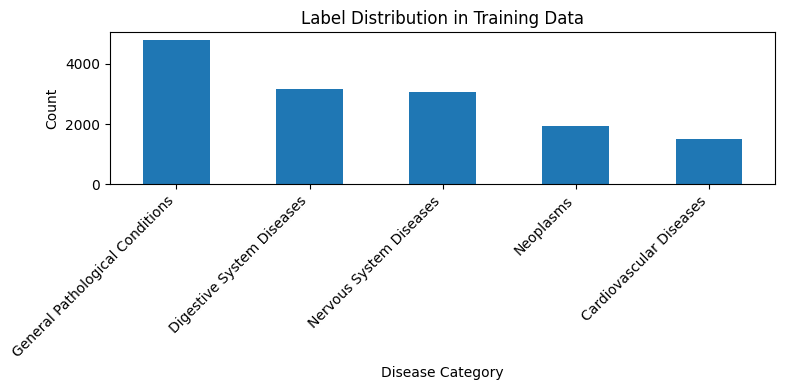

In [23]:

label_names = {
    1: "Digestive System Diseases",
    2: "Cardiovascular Diseases",
    3: "Neoplasms",
    4: "Nervous System Diseases",
    5: "General Pathological Conditions"
}
label_counts = train_df["label"].value_counts()
label_counts.index = label_counts.index.map(label_names)

label_counts.plot(kind="bar")
plt.title("Label Distribution in Training Data")
plt.xlabel("Disease Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Text Length Analysis

In [10]:
train_df["text_length"] = train_df["text"].apply(lambda x: len(x.split()))

train_df["text_length"].describe()

count    14438.000000
mean       179.937110
std         76.549766
min         24.000000
25%        122.000000
50%        176.000000
75%        235.000000
max        596.000000
Name: text_length, dtype: float64

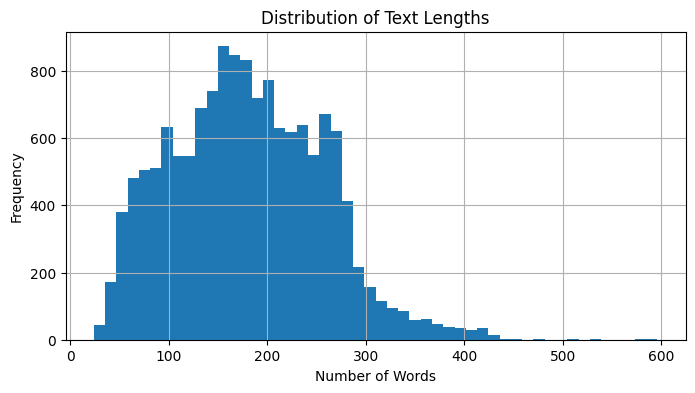

In [11]:
train_df["text_length"].hist(bins=50)
plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

## Most Common Words (Quick Sanity Check)

In [12]:
vectorizer = CountVectorizer(stop_words="english", max_features=50)
X = vectorizer.fit_transform(train_df["text"])

word_counts = np.sum(X.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

common_words = pd.DataFrame({
    "word": words,
    "count": word_counts
}).sort_values("count", ascending=False)

common_words.head(10)

,word,count
31,patients,34444
18,disease,7504
20,group,6389
44,treatment,6161
38,study,5512
30,patient,4892
6,blood,4562
9,cases,4490
49,years,4447
10,cell,4431


## Example Samples per Class

In [13]:
for label in train_df["label"].unique():
    print(f"\n--- Label: {label} ---")
    print(train_df[train_df["label"] == label]["text"].iloc[0][:300])


--- Label: 4 ---
Catheterization laboratory events and hospital outcome with direct angioplasty for acute myocardial infarction To assess the safety of direct infarct angioplasty without antecedent thrombolytic therapy, catheterization laboratory and hospital events were assessed in consecutively treated patients wi

--- Label: 5 ---
Renal abscess in children. Three cases of renal abscesses in children are described to illustrate the variable presenting features. An additional 23 pediatric cases, reported over the past ten years, were reviewed for clinical features and therapy. Fever, loin pain, and leukocytosis were common pres

--- Label: 2 ---
Hyperplastic polyps seen at sigmoidoscopy are markers for additional adenomas seen at colonoscopy. Asymptomatic individuals undergoing screening flexible sigmoidoscopy were prospectively studied. Polyps were found in 185 subjects. The endoscopist recorded an opinion on the polyps' histology based on

--- Label: 1 ---
Infection during chronic 

# Class weight

⚠️ Recommended Class Weights for Training:
Label 1: 0.9129
Label 2: 1.9328
Label 3: 1.5001
Label 4: 0.9464
Label 5: 0.6010


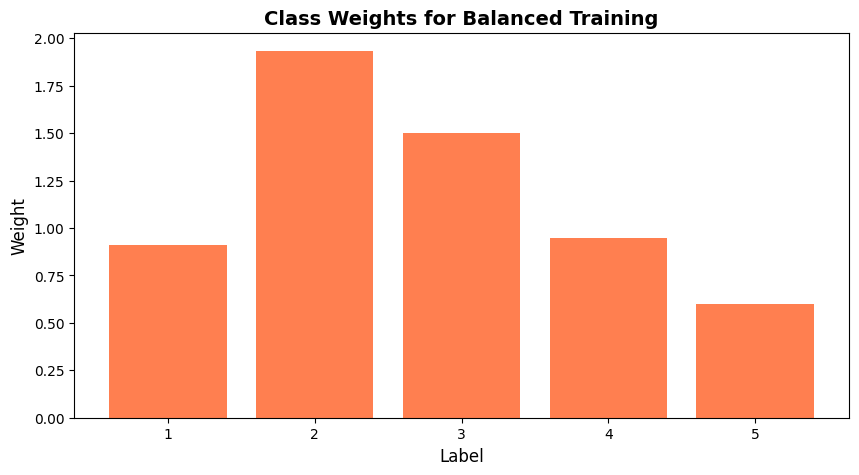

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights for balanced training
class_weights = compute_class_weight('balanced', 
                                     classes=np.unique(train_df['label']), 
                                     y=train_df['label'])
class_weight_dict = dict(zip(np.unique(train_df['label']), class_weights))

print("⚠️ Recommended Class Weights for Training:")
print("="*50)
for label, weight in sorted(class_weight_dict.items()):
    print(f"Label {label}: {weight:.4f}")

# Visualize
plt.figure(figsize=(10, 5))
labels_list = list(class_weight_dict.keys())
weights = list(class_weight_dict.values())
plt.bar(labels_list, weights, color='coral')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Weight', fontsize=12)
plt.title('Class Weights for Balanced Training', fontsize=14, fontweight='bold')
plt.show()